# 1. The model and its equilibrium properties

We ask whether the universal data of a conformal field theory, the central charge and the boundary
operator content, can be obtained from the real-time dynamics of a chain that is not integrable. The
model is an ANNNI-type chain: the transverse-field Ising model with a next-nearest-neighbour
coupling of strength $p$,

$$H = -\sum_i\left[\sigma^z_i\sigma^z_{i+1} + \lambda\,\sigma^x_i
+ p\left(\sigma^z_i\sigma^z_{i+2} + \lambda\,\sigma^x_i\sigma^x_{i+1}\right)\right].$$

It is self-dual for every $p$, critical at $\lambda = 1$, and interacting for any $p > 0$. Note the
convention: the field acts on $\sigma^x$ and the order parameter on $\sigma^z$, which is the
opposite of the Ising model built into the library.

The six notebooks follow the structure of the thesis: the model and its equilibrium properties here,
the method and its validation in notebook 2, the temporal entropies in notebook 3, the spectral
route in notebook 4, the boundary spectrum in notebook 5, and the numerical controls in notebook 6.
Long calculations are cached under `data/`, and the thesis figures are produced by the scripts in
`scripts/figures/`, which the notebooks include and call.

In [1]:
include("../src/thesislib.jl")
using JLD2, Printf, Statistics, LsqFit
thesis_plot_theme!()

## The entanglement barrier

We first evolve the quenched state $|X+\rangle^{\otimes N}$ in the usual way. The observable is the
Loschmidt amplitude $L(T) = \langle\psi_0|e^{-iHT}|\psi_0\rangle$ and its rate
$\ell(T) = -\log|L|/N$. The rate itself is well behaved, but the state is not: TDVP must increase
the bond dimension to keep $|\psi(t)\rangle$ faithful, and that growth is exponential. The run below
is cached, at $p=0.1$, $N=40$ and $\delta t = 0.05$, and tracks both quantities.

[ Info: All target T values already cached.


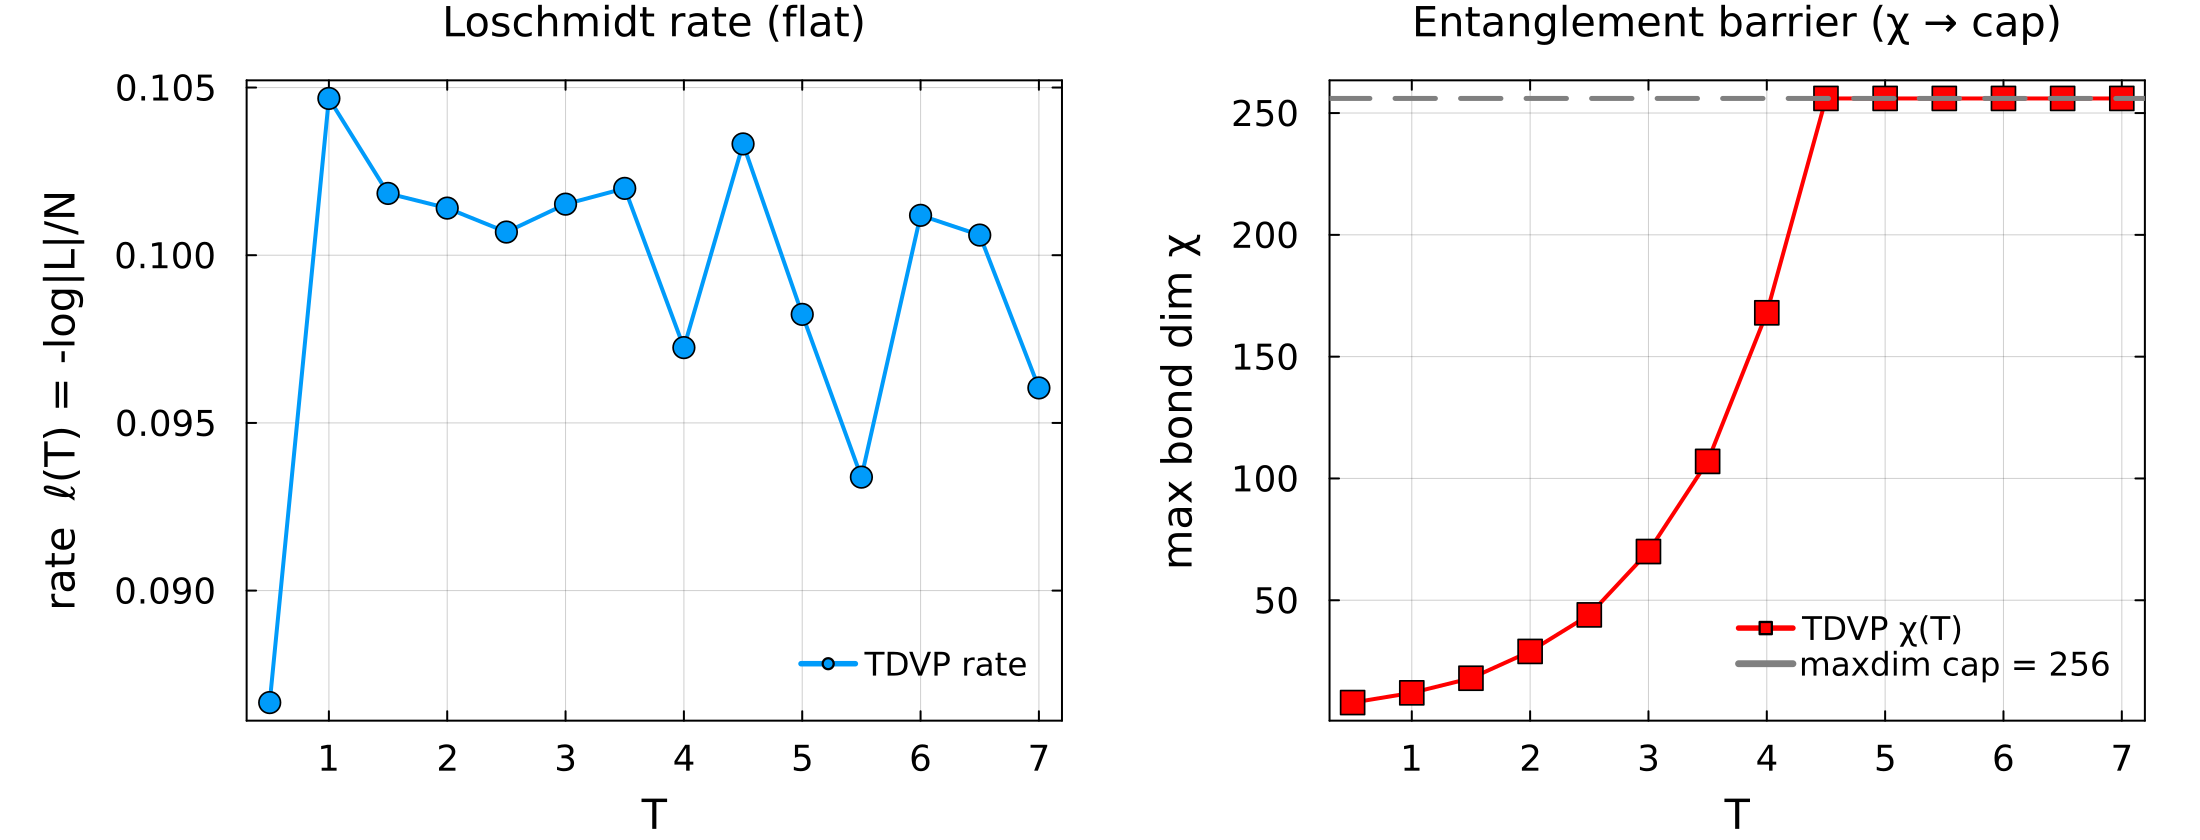

In [2]:
# TDVP Loschmidt run
# (loads from data/local/tdvp_loschmidt_p0.1_N40.jld2, computes only if a time is missing from the cache
tdvp = tdvp_loschmidt_amplitude(40, collect(0.5:0.5:7.0); p=0.1, lambda=1.0, dt=0.05)
Ts   = sort(collect(keys(tdvp)))
rate = [tdvp[T].rate   for T in Ts]
chi  = [tdvp[T].maxchi for T in Ts]

pr = plot(Ts, rate; xlabel="T", ylabel="rate  ℓ(T) = -log|L|/N", lw=2, marker=:circle,
          label="TDVP rate", title="Loschmidt rate (flat)")
pc = plot(Ts, chi;  xlabel="T", ylabel="max bond dim χ", lw=2, marker=:square, color=:red,
          label="TDVP χ(T)", title="Entanglement barrier (χ → cap)")
hline!(pc, [256]; ls=:dash, color=:gray, label="maxdim cap = 256")
plot(pr, pc; layout=(1, 2), size=(1100, 420), margin=5Plots.mm)

The rate is smooth, but $\chi$ grows roughly exponentially and reaches the cap of $\chi = 256$ near
$T \approx 4.5$. Past that point the state is heavily truncated and the simulation is no longer
faithful. This is the entanglement barrier, and it is the reason we contract the space-time network
along the spatial direction instead. Transverse contraction replaces the growing spatial
entanglement by the temporal entanglement, which after a critical quench grows only
logarithmically. Notebook 2 covers that construction. The rest of this notebook establishes the two
equilibrium quantities it needs.

## Universality class

We determine the universality class from the ground state, independently of any dynamics. At a
critical point the entanglement entropy of a block of $l$ sites out of $L$ follows
$$S(l,L) = \tfrac{c}{6}W(l,L) + k$$

with the chord variable $W = \ln\left[\tfrac{2L}{\pi}\sin\tfrac{\pi l}{L}\right]$, so a linear fit against $W$ gives $c$
from its slope.

We first run this on a chain short enough to solve here: DMRG at $N = 64$, every cut, one fit.

N = 64, p = 0.1:  slope = 0.08587  ->  c = 6 x slope = 0.5152   (Ising: 0.5)


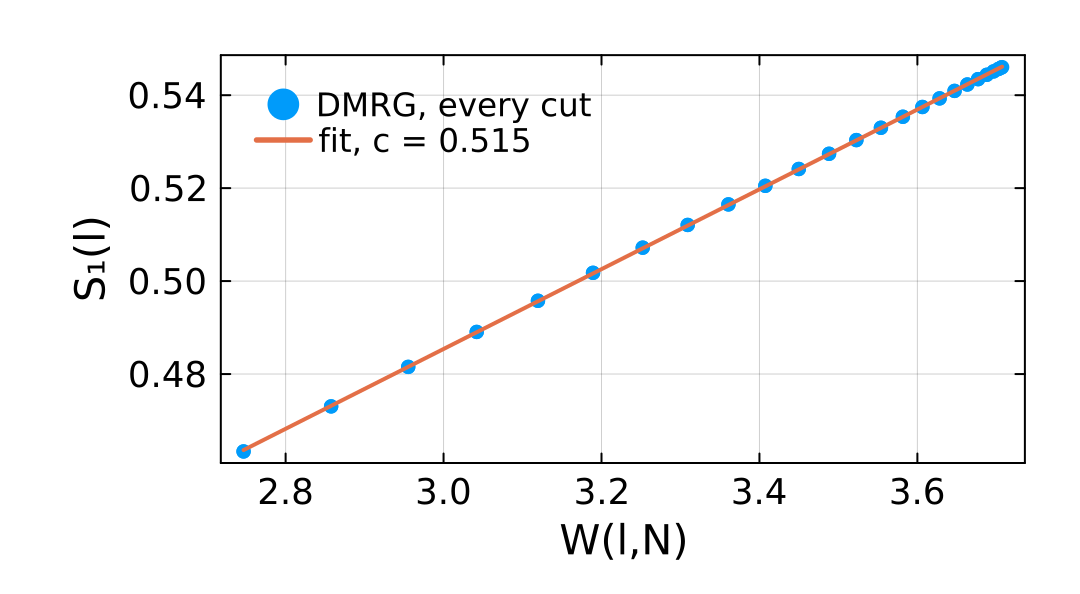

In [3]:
# ground state by DMRG, entropy at every cut, slope against the chord variable
N, p = 64, 0.1
sites = siteinds("S=1/2", N)
_, psi = dmrg(alcaraz_H(sites, 1.0, p), randomMPS(sites, 10);
              nsweeps=10, maxdim=[10, 20, 100, 200], cutoff=[1e-10], outputlevel=0)

S = compute_vn_entropy(psi)
W(l, L) = log((2L / pi) * sin(pi * l / L))
ls = 8:(N - 8)                       # drop the ends, where the chord form does not apply
Ws, Ss = [W(l, N) for l in ls], [S[l] for l in ls]
fit = curve_fit((x, q) -> q[1] .* x .+ q[2], Ws, Ss, [0.08, 0.5])
@printf("N = %d, p = %.1f:  slope = %.5f  ->  c = 6 x slope = %.4f   (Ising: 0.5)\n",
        N, p, fit.param[1], 6 * fit.param[1])

pl = plot(Ws, Ss; seriestype=:scatter, ms=4, msw=0, label="DMRG, every cut",
          xlabel="W(l,N)", ylabel="S₁(l)", size=thesis_size(0.7; aspect=0.55))
plot!(pl, Ws, fit.param[1] .* Ws .+ fit.param[2]; lw=2, label=@sprintf("fit, c = %.3f", 6fit.param[1]))

A short chain overshoots slightly, which is the finite-size correction the thesis includes in its
fits. The same procedure at $N = 300$ across a grid of couplings gives the result below, which stays
at $c = 1/2$ up to $p = 1.5$ (`scripts/analysis/equilibrium_dmrg.jl`).

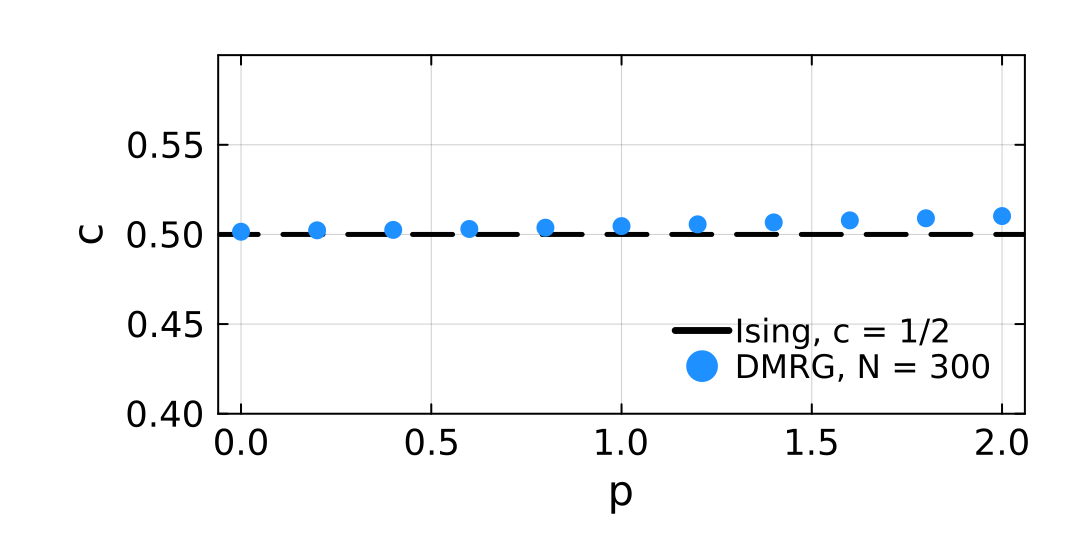

In [4]:
# c(p) from the N = 300 sweep, produced by scripts/analysis/equilibrium_dmrg.jl
cvsp = load("../data/local/nb4_cvsp.jld2")
pl = plot(xlabel="p", ylabel="c", legend=:bottomright, ylims=(0.4, 0.6),
          size=thesis_size(0.7; aspect=0.5))
hline!(pl, [0.5], color=:black, ls=:dash, label="Ising, c = 1/2")
scatter!(pl, cvsp["p"], cvsp["c"], color=:dodgerblue, ms=5, msw=0, label="DMRG, N = 300")
pl

The careful version of the same statement is the finite-size scaling of the thesis: two couplings
and two estimators, with panel (b) showing the subleading correction on its own, so that the fit can
be seen to describe the data rather than absorb it.

p=0.1  n=1 :  c = 0.5001   A = -0.154
p=0.5  n=1 :  c = 0.4997   A = -0.202


p=0.1  n=2 :  c = 0.5081   A = -0.178
p=0.5  n=2 :  c = 0.5048   A = -0.195


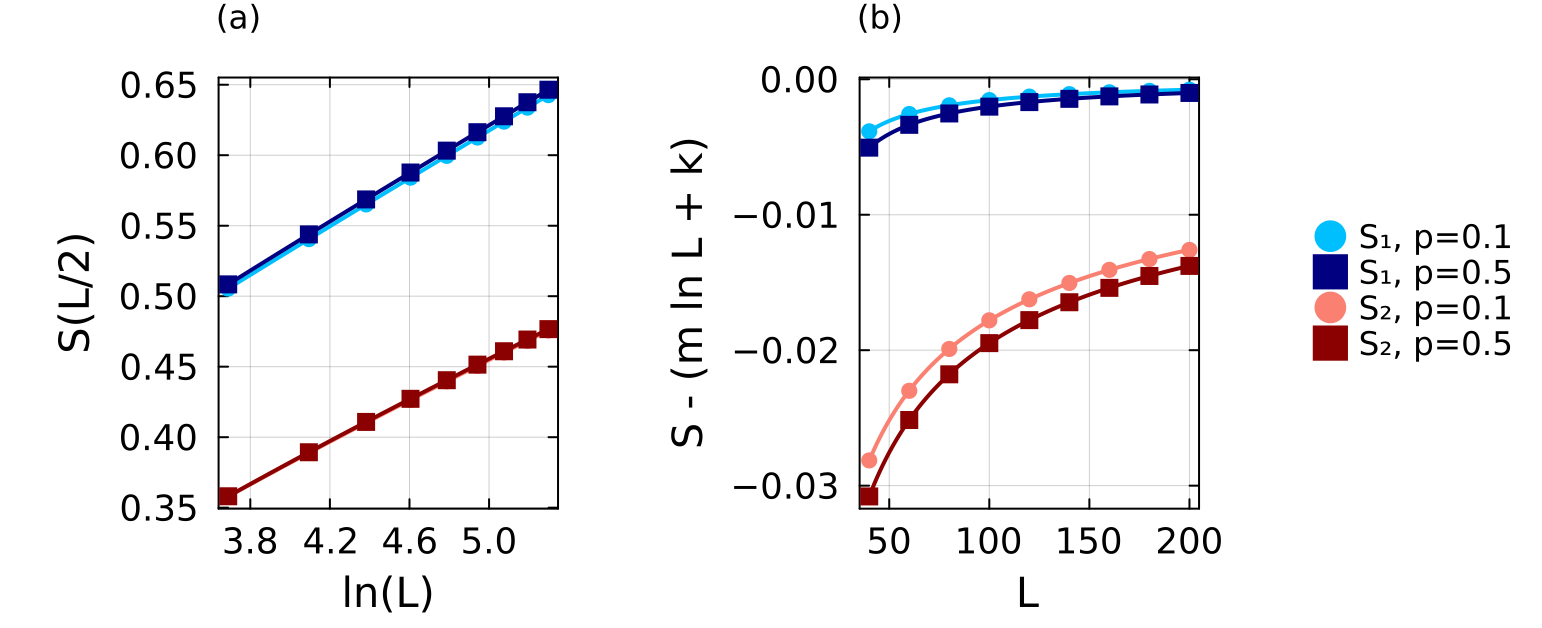

In [5]:
# the finite-size scaling of fig:cft_L, from data/local/nb4_fss.jld2
include("../scripts/figures/fig_cft_L.jl")
make_cft_L()

A second check uses one long chain, $N = 400$, and all cuts at once. Against the chord variable the
profile is a straight line of slope $c/6$. Eight couplings give eight slopes, all at
$c \approx 0.502$, up to $p = 1.5$.

p=0.00 : c = 0.5020
p=0.10 : c = 0.5018


p=0.20 : c = 0.5018
p=0.30 : c = 0.5019
p=0.40 : c = 0.5020
p=0.50 : c = 0.5021
p=1.00 : c = 0.5036
p=1.50 : c = 0.5055
spread across p: 0.0449 at the first cut, 0.0204 at the central cut


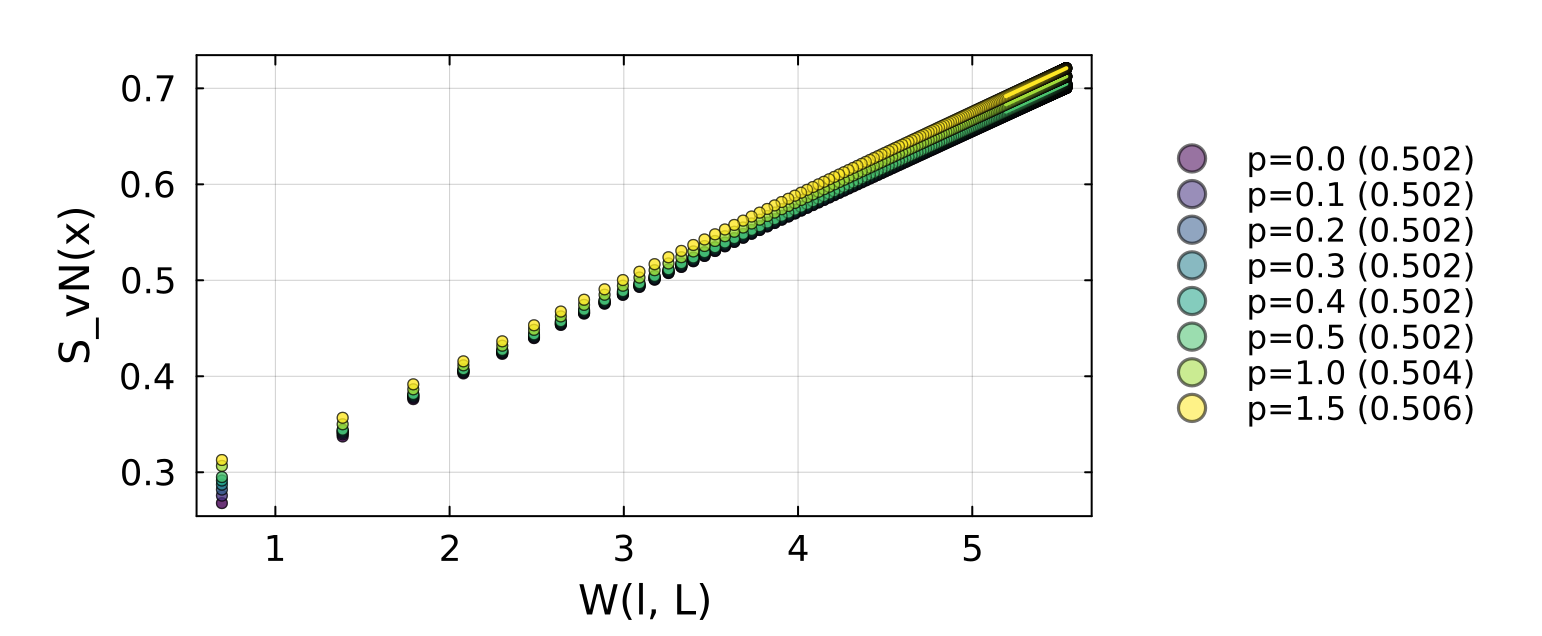

In [6]:
# the N = 400 profile of fig:cft_chord, from data/local/nb4_chord_N400.jld2
include("../scripts/figures/fig_chord_equilibrium.jl")
make_chord_equilibrium()

## The sound velocity

The dynamical measurements return phases, and converting a phase gap into a scaling dimension
requires the sound velocity $v(p)$, which is not universal. We measure it by exact diagonalisation
on periodic rings.

The estimator is the energy difference at the smallest non-zero momentum, taken between two states
of the same tower so that the unknown scaling dimension cancels. On rings small enough to
diagonalise exactly it converges as $1/N^2$. At $p = 0$ the exact value is $v = 2$, which is the
control.

In [7]:
# same-tower energy difference on exact-diagonalisation rings, extrapolated in 1/N^2
finite_size_velocity(N, p) = (r = ground_and_gap(N, 1.0, p);
    N * (r.e1_nonzero - r.e1_zero) / (2pi * abs(r.smallest_momentum)))

Ns = [10.0, 12, 14, 16]
vs = [finite_size_velocity(Int(N), 0.0) for N in Ns]
for (N, v) in zip(Ns, vs)
    @printf("N = %2d   v(N) = %.5f\n", Int(N), v)
end
a, b = hcat(ones(length(Ns)), 1 ./ Ns .^ 2) \ vs
@printf("extrapolated v_inf = %.5f   (exact: 2)\n", a)

N = 10   v(N) = 1.96726
N = 12   v(N) = 1.97723


N = 14   v(N) = 1.98326
N = 16   v(N) = 1.98717
extrapolated v_inf = 1.99993   (exact: 2)


Repeating this at every coupling, up to $N = 18$, gives the velocities used in notebooks 4 and 5.
The producer is `scripts/analysis/equilibrium_velocity.jl`.

v_inf(p): v(0.0)=2.000  v(0.1)=2.670  v(0.2)=3.326  v(0.3)=3.967  v(0.4)=4.596  v(0.5)=5.212  v(1.0)=8.126  v(1.5)=10.799


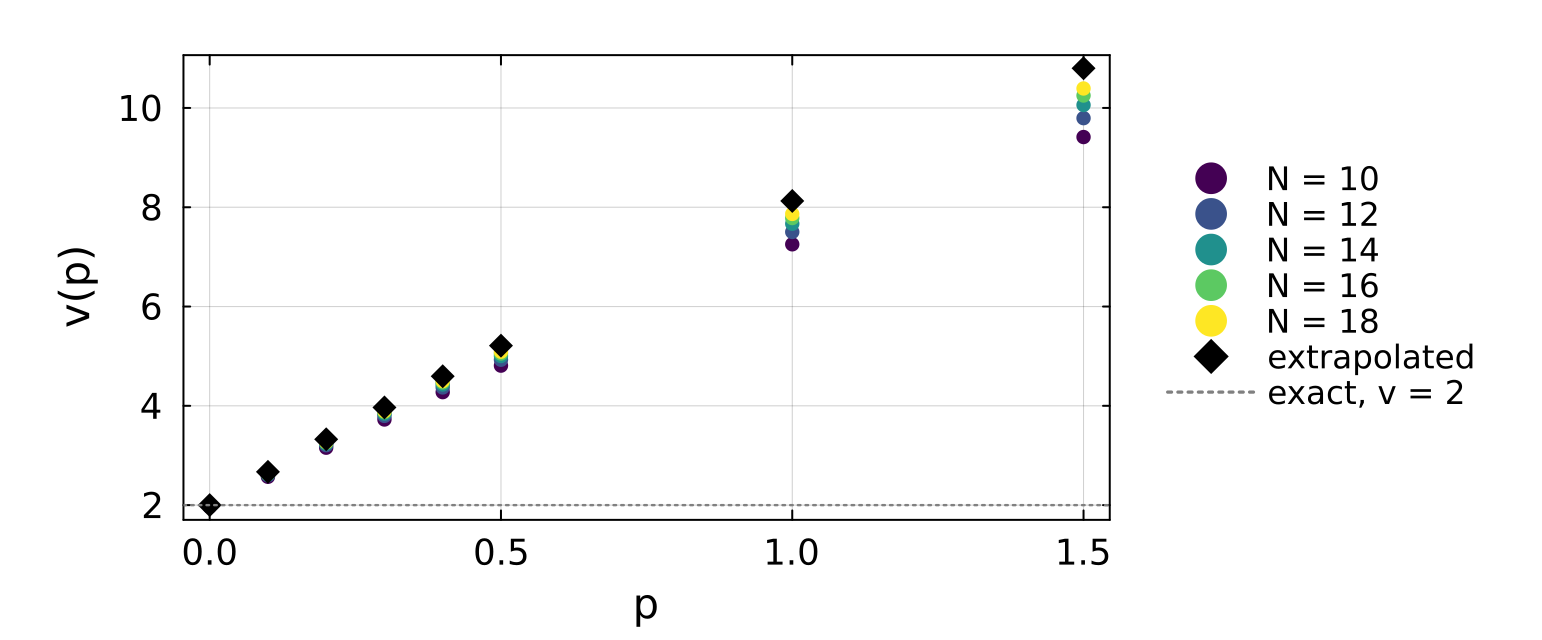

In [8]:
# v(p) and the 1/N^2 extrapolation, from data/local/nb4_velocity_sizes.jld2
include("../scripts/figures/fig_velocity_vs_p.jl")
make_velocity_vs_p()

p=0: intercept 1.99994, exact 2, error 6.0e-05


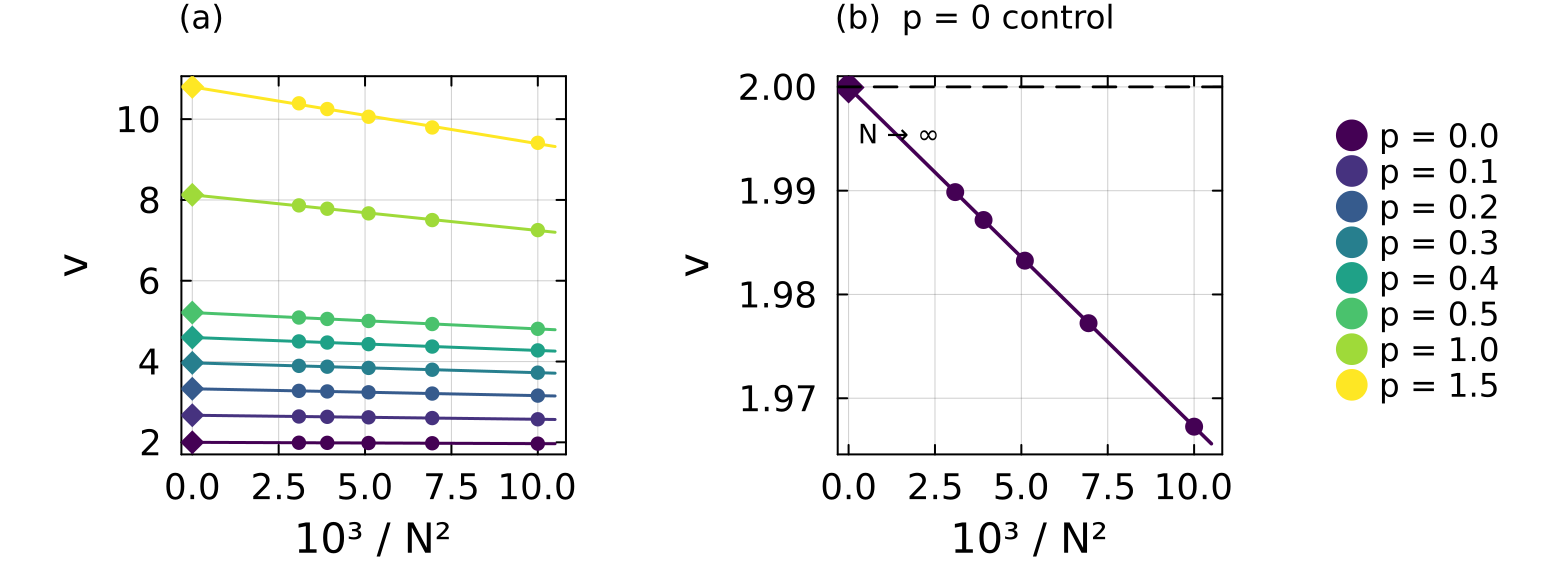

In [9]:
include("../scripts/figures/fig_velocity_extrap.jl")
make_velocity_extrap()

Three results are used in the rest of the project. Direct evolution reproduces the echo but reaches
the entanglement barrier by $T \approx 4.5$ at $N = 40$. The model remains in the Ising class over
the whole range, according to two independent equilibrium estimators. The extrapolated velocities,
2.000, 2.670, 3.326, 3.967, 4.596 and 5.212 for $p = 0$ to $0.5$, are stored in
`data/local/alcaraz_velocity.jld2` and enter every conversion in notebooks 4 and 5.